In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="KCQOXriM5jQO5ioeSPDg")
project = rf.workspace("1-c9cyg").project("under-water-smqxk")
version = project.version(1)
dataset = version.download("yolov7")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 247.9 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 197.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 219.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 207.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 172.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 91.6 MB/s  0:00:00
  Attempting uninstall: idna90m╺━━━━━━━━━━━━━━━━━━━━━━━━━  6/17 [numpy]]ng]
    Found existing installation: idna 3.11━━━━━━━━━━━━━━━━━━━━  6/17 [numpy]
    Uninstalling idna-3.11:╺━━━━━━━━━━━━━━━━━━━━━━━━━  6/17 [numpy]
      Successfully uninstalled idna-3.11━━━━━━━━━━━━━━━━━━━━━━  6/17 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [roboflow]/17 [roboflow]b]on-headless]
load


Extracting Dataset Version Zip to under-water-1 in yolov7pytorch:: 100%|██████████| 11096/11096 [00:04<00:00, 2740.59it/s]


In [2]:
import cv2
import os
import numpy as np

def enhance_image(img):
    # Convert to LAB color space
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # CLAHE on L channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    limg = cv2.merge((cl, a, b))
    enhanced = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

    return enhanced

input_dir = "/content/underwater_dataset/images/train"
output_dir = "/content/underwater_dataset/images/train_enhanced"

os.makedirs(output_dir, exist_ok=True)

for img_name in os.listdir(input_dir):
    img_path = os.path.join(input_dir, img_name)
    img = cv2.imread(img_path)
    if img is None:
        continue

    enhanced = enhance_image(img)
    cv2.imwrite(os.path.join(output_dir, img_name), enhanced)


FileNotFoundError: [Errno 2] No such file or directory: '/content/underwater_dataset/images/train'

In [3]:
!pwd


/teamspace/studios/this_studio


In [4]:
!ls



 Untitled.ipynb   main.py  'under water.v1i.yolov7pytorch.zip'	 under-water-1


In [7]:
!pwd



/teamspace/studios/this_studio


In [8]:
!ls

 Untitled.ipynb   main.py  'under water.v1i.yolov7pytorch.zip'	 under-water-1


In [9]:
!ls under-water-1


README.dataset.txt  README.roboflow.txt  data.yaml  test  train  valid


In [11]:
!cat under-water-1/data.yaml


names:
- echinus
- holothurian
- scallop
- starfish
- waterweeds
nc: 5
roboflow:
  license: CC BY 4.0
  project: under-water-smqxk
  url: https://universe.roboflow.com/1-c9cyg/under-water-smqxk/dataset/1
  version: 1
  workspace: 1-c9cyg
test: ../test/images
train: under-water-1/train/images
val: under-water-1/valid/images


In [1]:
import cv2
import os

def enhance_image(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    limg = cv2.merge((cl, a, b))
    enhanced = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
    return enhanced


input_dir = "under-water-1/train/images"
output_dir = "under-water-1/train/images_enhanced"

os.makedirs(output_dir, exist_ok=True)

for img_name in os.listdir(input_dir):
    img_path = os.path.join(input_dir, img_name)
    img = cv2.imread(img_path)
    if img is None:
        continue

    enhanced = enhance_image(img)
    cv2.imwrite(os.path.join(output_dir, img_name), enhanced)

print("Training images enhanced successfully.")


Training images enhanced successfully.


In [3]:
!rm -rf under-water-1/train/images
!mv under-water-1/train/images_enhanced under-water-1/train/images


In [4]:
len(os.listdir("under-water-1/train/images"))


3879

In [5]:
!python train.py \
--img 640 \
--batch 16 \
--epochs 50 \
--data under-water-1/data.yaml \
--weights yolov7.pt \
--name yolov7_underwater


/home/zeus/miniconda3/envs/cloudspace/bin/python: can't open file '/teamspace/studios/this_studio/train.py': [Errno 2] No such file or directory


In [6]:
!git clone https://github.com/WongKinYiu/yolov7.git


Cloning into 'yolov7'...



In [7]:
!ls yolov7


LICENSE.md  deploy     hubconf.py  requirements.txt  train.py
README.md   detect.py  inference   scripts	     train_aux.py
cfg	    export.py  models	   test.py	     utils
data	    figure     paper	   tools


In [8]:
%cd yolov7


/teamspace/studios/this_studio/yolov7


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [9]:
!pwd


/teamspace/studios/this_studio/yolov7


In [10]:
!pip install -r requirements.txt


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 138.9 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      Traceback (most recent call last):
        File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
        File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 137, in get_requires_for_build_wheel

In [1]:
conda create -n yolov7 python=3.9 -y


Error: Conda create is not allowed. A Studio has a default conda environment (max 1 environment). Start a new Studio to create a new environment.

Note: you may need to restart the kernel to use updated packages.


In [2]:
conda activate yolov7


Error: Conda activate is not allowed. A Studio has a default conda environment (max 1 environment). Start a new Studio to create a new environment.

Note: you may need to restart the kernel to use updated packages.


In [4]:
!python --version


Python 3.12.11


In [5]:
pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 214.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 805.7/805.7 kB 49.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 MB 187.1 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 165.0 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 56.6 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 136.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 81.4 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 198.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 279.4 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 63.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 60.2 MB/s  0:00:05m0:00:0100:01

In [1]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")
model.train(
    data="under-water-1/data.yaml",
    imgsz=640,
    epochs=50,
    batch=16
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/teamspace/studios/this_studio/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.9 🚀 Python-3.12.11 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=under-water-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=

RuntimeError: Dataset 'under-water-1/data.yaml' error ❌ Dataset 'under-water-1/data.yaml' images not found, missing path '/teamspace/studios/this_studio/under-water-1/under-water-1/valid/images'
Note dataset download directory is '/teamspace/studios/this_studio/datasets'. You can update this in '/teamspace/studios/this_studio/.config/Ultralytics/settings.json'

In [3]:
!nano under-water-1/data.yaml


/bin/bash: line 1: nano: command not found


In [6]:
!path: /teamspace/studios/this_studio/under-water-1

train: train/images
val: valid/images
test: test/images

nc: 5
!names:
  - echinus
  - holothurian
  - scallop
  - starfish
  - waterweeds


IndentationError: unexpected indent (1241339485.py, line 9)

In [7]:
yaml_content = """path: /teamspace/studios/this_studio/under-water-1

train: train/images
val: valid/images
test: test/images

nc: 5
names:
  - echinus
  - holothurian
  - scallop
  - starfish
  - waterweeds
"""

with open("under-water-1/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml updated successfully")


data.yaml updated successfully


In [8]:
!cat under-water-1/data.yaml


path: /teamspace/studios/this_studio/under-water-1

train: train/images
val: valid/images
test: test/images

nc: 5
names:
  - echinus
  - holothurian
  - scallop
  - starfish
  - waterweeds


In [9]:
!ls under-water-1/train/images | head
!ls under-water-1/valid/images | head
!ls under-water-1/test/images | head


000001_jpg.rf.1e5042a6782f8b701b225f389cc73eba.jpg
000003_jpg.rf.52c07c83fa5df2470a2d99d63a79fa8f.jpg
000005_jpg.rf.438ecd6080e21dcd22be04c1086f85b1.jpg
000006_jpg.rf.2317f6153341c8ec176501f86b940e15.jpg
000010_jpg.rf.d6bed64900bcafec342ff3bad60db4d5.jpg
000011_jpg.rf.8b9571d8158d5501c373b66b48b886d4.jpg
000012_jpg.rf.28e56df3ec6872a72157662101e68a19.jpg
000014_jpg.rf.668ecc033614c37d32d9bd0f972dbe08.jpg
000016_jpg.rf.7b9cb55bf4bde20839b8ee0af993f288.jpg
000017_jpg.rf.84f4dd420e2f371f35ab3bcd9ae1797a.jpg
ls: write error: Broken pipe
000007_jpg.rf.df4b1e1a42372f9a43ee83fe67e44c74.jpg
000015_jpg.rf.f8a28f4cd01e5826448acb3dce375ad6.jpg
000019_jpg.rf.866f15cf5445196ee52be69d97983604.jpg
000021_jpg.rf.771d4b6c42286f30efecb9b49275112f.jpg
000023_jpg.rf.f6fed091a1b2ac8dd76b35e56bcf3242.jpg
000024_jpg.rf.1e3acfd63450e1c8552a25415a73e0e5.jpg
000025_jpg.rf.eb4873d6e6eaa7a42e5c95a849073d68.jpg
000028_jpg.rf.993ae955fbc56fc5659a8f0b33129d5b.jpg
000032_jpg.rf.b8f95ff8c4fceb1102bc53523b99dcad.jpg
00

In [10]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.train(
    data="under-water-1/data.yaml",
    imgsz=640,
    epochs=50,
    batch=16,
    device=0
)


Ultralytics 8.4.9 🚀 Python-3.12.11 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=under-water-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plo

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x76cd3a744410>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [11]:
from ultralytics import YOLO

# Load trained model
model = YOLO("runs/detect/train2/weights/best.pt")

# Run inference on test images
results = model.predict(
    source="under-water-1/test/images",
    imgsz=640,
    conf=0.25,
    save=True,
    device=0
)



image 1/554 /teamspace/studios/this_studio/under-water-1/test/images/000002_jpg.rf.cff5314e9ffaddfca8372bffc69fc9e5.jpg: 384x640 4 echinuss, 1 scallop, 47.5ms
image 2/554 /teamspace/studios/this_studio/under-water-1/test/images/000008_jpg.rf.9b71299435cabb5d0e6d4c185e0b83db.jpg: 384x640 4 echinuss, 11.0ms
image 3/554 /teamspace/studios/this_studio/under-water-1/test/images/000009_jpg.rf.6ef17910026b22205bacd35c65ce2e2c.jpg: 384x640 2 echinuss, 3 holothurians, 1 starfish, 11.0ms
image 4/554 /teamspace/studios/this_studio/under-water-1/test/images/000013_jpg.rf.d92cfdba76a1f0052d51c6e300cf5846.jpg: 384x640 1 holothurian, 2 starfishs, 11.0ms
image 5/554 /teamspace/studios/this_studio/under-water-1/test/images/000038_jpg.rf.d01fcb97419dc2c406fb11eede40753f.jpg: 384x640 2 starfishs, 11.0ms
image 6/554 /teamspace/studios/this_studio/under-water-1/test/images/000047_jpg.rf.365a10958375c21f1ec6fa7e76accb09.jpg: 384x640 3 echinuss, 11.0ms
image 7/554 /teamspace/studios/this_studio/under-water-

In [12]:
metrics = model.val(
    data="under-water-1/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device=0
)

print(metrics)


Ultralytics 8.4.9 🚀 Python-3.12.11 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1300.9±1148.0 MB/s, size: 104.9 KB)
val: Scanning /teamspace/studios/this_studio/under-water-1/test/labels... 554 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 554/554 1.6Kit/s 0.4s0.1ss
val: New cache created: /teamspace/studios/this_studio/under-water-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 3.2it/s 11.0s0.2s
                   all        554       4563      0.768      0.595      0.687      0.391
               echinus        430       2415      0.893      0.747      0.869      0.491
           holothurian        244        602      0.838      0.553        0.7      0.389
               scallop        125        762      0.898      0.568      0.762      0.483
              starfish        286        771      0.782        0.8      0.844      0.499
           

In [13]:
metrics.results_dict


{'metrics/precision(B)': 0.7681385168378979,
 'metrics/recall(B)': 0.5952878285935649,
 'metrics/mAP50(B)': 0.6865722406762081,
 'metrics/mAP50-95(B)': 0.39106969903690625,
 'fitness': 0.39106969903690625}

In [8]:
!ls runs/detect/train2


BoxF1_curve.png			 results.csv	      val_batch0_labels.jpg
BoxPR_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxR_curve.png			 train_batch1.jpg     val_batch1_pred.jpg
args.yaml			 train_batch2.jpg     val_batch2_labels.jpg
confusion_matrix.png		 train_batch9720.jpg  val_batch2_pred.jpg
confusion_matrix_normalized.png  train_batch9721.jpg  weights
labels.jpg			 train_batch9722.jpg


In [1]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
qual_path = Path("runs/detect/val")


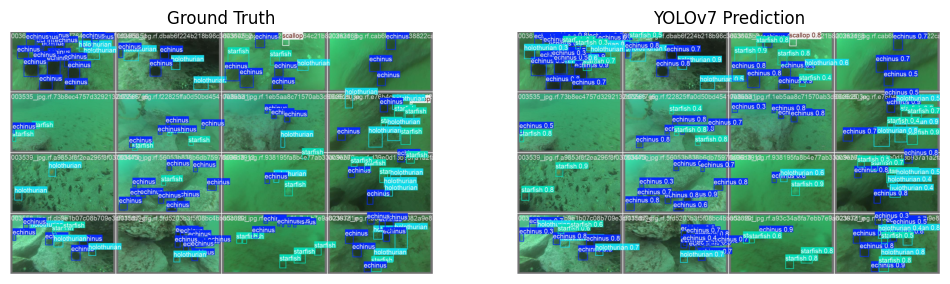

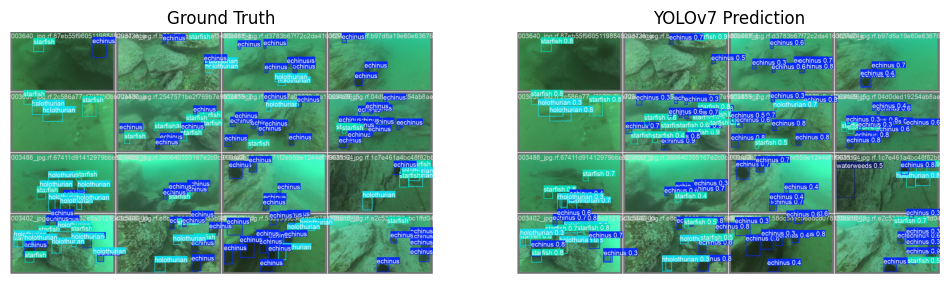

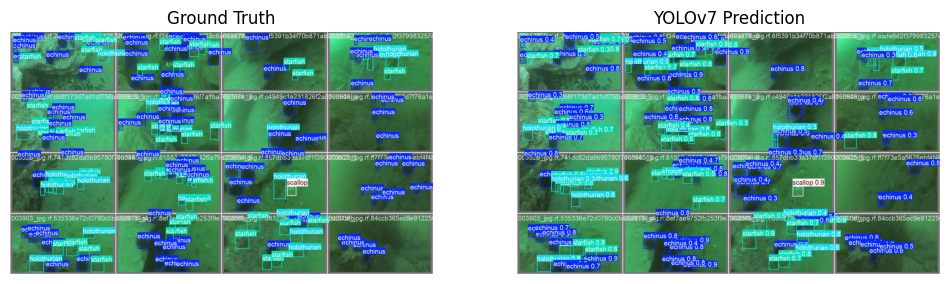

In [3]:
pairs = [
    ("val_batch0_labels.jpg", "val_batch0_pred.jpg"),
    ("val_batch1_labels.jpg", "val_batch1_pred.jpg"),
    ("val_batch2_labels.jpg", "val_batch2_pred.jpg")
]

for gt, pred in pairs:
    gt_img = cv2.imread(str(qual_path / gt))
    pred_img = cv2.imread(str(qual_path / pred))

    gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)
    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(gt_img)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(pred_img)
    plt.title("YOLOv7 Prediction")
    plt.axis("off")

    plt.show()


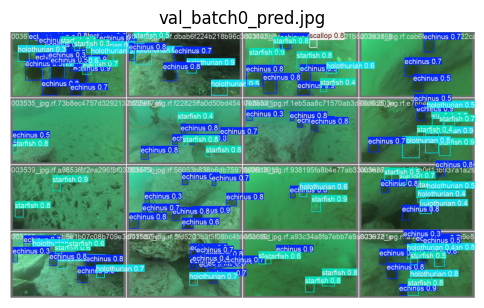

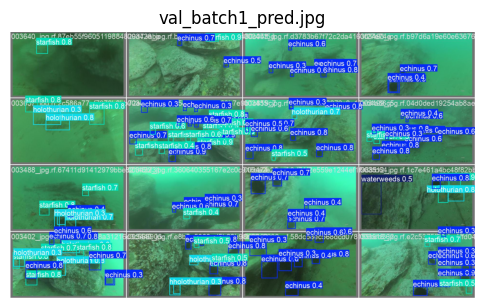

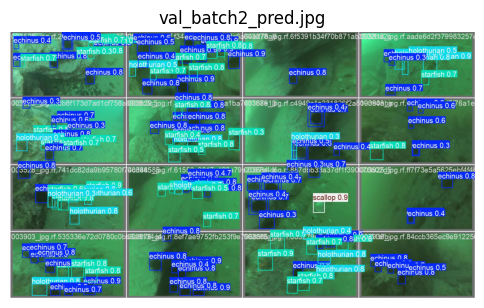

In [4]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

qual_path = Path("runs/detect/val")
pred_images = sorted(qual_path.glob("val_batch*_pred.jpg"))

for img_path in pred_images:
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,4))
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()


In [5]:
import shutil
import os

# Source folder where YOLOv7 validation predictions are saved
src = "runs/detect/val"

# Destination folder for qualitative analysis
dst = "qualitative_results_yolov7"

os.makedirs(dst, exist_ok=True)

# Copy first 10 predicted images
files = os.listdir(src)

count = 0
for f in files:
    if f.endswith("_pred.jpg"):   # only prediction images
        shutil.copy(os.path.join(src, f), dst)
        count += 1
    if count == 10:
        break

print("Copied YOLOv7 qualitative images successfully.")


Copied YOLOv7 qualitative images successfully.


In [6]:
import os
import cv2

src_img = "runs/detect/val"
src_lbl = "runs/detect/val/labels"
dst = "qualitative_results_yolov7_boxes"

os.makedirs(dst, exist_ok=True)


In [7]:
names = [
    "echinus",
    "holothurian",
    "scallop",
    "starfish",
    "waterweeds"
]


In [8]:
img_files = [f for f in os.listdir(src_img) if f.endswith(".jpg")]

count = 0

for img_name in img_files:
    img_path = os.path.join(src_img, img_name)
    label_path = os.path.join(src_lbl, img_name.replace(".jpg", ".txt"))

    if not os.path.exists(label_path):
        continue

    img = cv2.imread(img_path)
    h, w, _ = img.shape

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        cls_id = int(parts[0])
        x, y, bw, bh = map(float, parts[1:5])
        conf = float(parts[5]) if len(parts) == 6 else 1.0

        # Convert YOLO to pixel coords
        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        crop = img[max(0,y1):min(h,y2), max(0,x1):min(w,x2)]

        if crop.size == 0:
            continue

        cls_name = names[cls_id]
        out_name = f"{cls_name}_{conf:.2f}_{count}.jpg"
        cv2.imwrite(os.path.join(dst, out_name), crop)

        count += 1

        if count >= 15:   # limit for qualitative analysis
            break
    if count >= 15:
        break

print("YOLOv7 one-box-per-image qualitative results saved.")


YOLOv7 one-box-per-image qualitative results saved.


In [9]:
import os
print(os.getcwd())


/teamspace/studios/this_studio


In [10]:
import os

print("Detect folder exists:", os.path.exists("runs/detect/val"))
print("Labels folder exists:", os.path.exists("runs/detect/val/labels"))

if os.path.exists("runs/detect/val"):
    print("Files in detect/val:", os.listdir("runs/detect/val"))


Detect folder exists: True
Labels folder exists: False
Files in detect/val: ['val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'BoxPR_curve.png', 'confusion_matrix_normalized.png', 'val_batch2_labels.jpg', 'BoxR_curve.png', 'val_batch1_pred.jpg', 'val_batch2_pred.jpg', 'confusion_matrix.png', 'BoxP_curve.png', 'val_batch1_labels.jpg', 'BoxF1_curve.png']


In [12]:
!python detect.py \
  --weights runs/train/yolov7_underwater/best.pt \
  --source ../under-water-1/valid/images \
  --img 640 \
  --conf 0.25 \
  --save-txt \
  --save-conf \
  --project runs/detect \
  --name val


/home/zeus/miniconda3/envs/cloudspace/bin/python: can't open file '/teamspace/studios/this_studio/detect.py': [Errno 2] No such file or directory


In [3]:
cd yolov7


/teamspace/studios/this_studio/yolov7


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [18]:
!python detect.py \
--weights runs/train/yolov7_underwater/weights/best.pt \
--source ../under-water-1/valid/images \
--img 640 \
--conf 0.25 \
--save-txt \
--save-conf \
--project runs/detect \
--name val \
--exist-ok



Traceback (most recent call last):
  File "/teamspace/studios/this_studio/yolov7/detect.py", line 10, in <module>
    from models.experimental import attempt_load
  File "/teamspace/studios/this_studio/yolov7/models/experimental.py", line 6, in <module>
    from models.common import Conv, DWConv
  File "/teamspace/studios/this_studio/yolov7/models/common.py", line 6, in <module>
    import pandas as pd
ModuleNotFoundError: No module named 'pandas'


In [19]:
ls runs/detect/val/labels


ls: cannot access 'runs/detect/val/labels': No such file or directory


In [22]:
runs/detect/train2/weights/best.pt

/bin/bash: line 1: cd: yolov7: No such file or directory


In [23]:
pip install pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 132.6 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [4]:
!python detect.py \
--weights runs/detect/train2/weights/best.pt \
--source ../under-water-1/test/images \
--img 640 \
--conf 0.25 \
--save-txt \
--save-conf \
--project runs/qualitative \
--name yolov7_results \
--exist-ok


/home/zeus/miniconda3/envs/cloudspace/bin/python: can't open file '/teamspace/studios/this_studio/detect.py': [Errno 2] No such file or directory


In [5]:
cd yolov7


/teamspace/studios/this_studio/yolov7


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
ls detect.py


detect.py*


In [8]:
!python detect.py \
--weights ../runs/detect/train2/weights/best.pt \
--source ../under-water-1/test/images \
--img 640 \
--conf 0.25 \
--save-txt \
--save-conf \
--project ../runs/qualitative \
--name yolov7_results \
--exist-ok


Namespace(weights=['../runs/detect/train2/weights/best.pt'], source='../under-water-1/test/images', img_size=640, conf_thres=0.25, iou_thres=0.45, device='', view_img=False, save_txt=True, save_conf=True, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project='../runs/qualitative', name='yolov7_results', exist_ok=True, no_trace=False)
YOLOR 🚀 v0.1-128-ga207844 torch 2.10.0+cu128 CUDA:0 (Tesla T4, 15095.0625MB)

Traceback (most recent call last):
  File "/teamspace/studios/this_studio/yolov7/detect.py", line 196, in <module>
    detect()
  File "/teamspace/studios/this_studio/yolov7/detect.py", line 34, in detect
    model = attempt_load(weights, map_location=device)  # load FP32 model
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/teamspace/studios/this_studio/yolov7/models/experimental.py", line 252, in attempt_load
    ckpt = torch.load(w, map_location=map_location)  # load
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/hom

In [1]:
!export TORCH_WEIGHTS_ONLY=0


In [2]:
cd yolov7


/teamspace/studios/this_studio/yolov7


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
!export TORCH_WEIGHTS_ONLY=0


In [5]:
!python detect.py \
--weights ../runs/detect/train2/weights/best.pt \
--source ../under-water-1/test/images \
--img 640 \
--conf 0.25 \
--save-txt \
--save-conf \
--project ../runs/qualitative \
--name yolov7_results \
--exist-ok


Namespace(weights=['../runs/detect/train2/weights/best.pt'], source='../under-water-1/test/images', img_size=640, conf_thres=0.25, iou_thres=0.45, device='', view_img=False, save_txt=True, save_conf=True, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project='../runs/qualitative', name='yolov7_results', exist_ok=True, no_trace=False)
YOLOR 🚀 v0.1-128-ga207844 torch 2.10.0+cu128 CUDA:0 (Tesla T4, 15095.0625MB)

Traceback (most recent call last):
  File "/teamspace/studios/this_studio/yolov7/detect.py", line 196, in <module>
    detect()
  File "/teamspace/studios/this_studio/yolov7/detect.py", line 34, in detect
    model = attempt_load(weights, map_location=device)  # load FP32 model
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/teamspace/studios/this_studio/yolov7/models/experimental.py", line 252, in attempt_load
    ckpt = torch.load(w, map_location=map_location)  # load
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/hom

In [7]:
!python - <<EOF
import torch
ckpt = torch.load("../runs/detect/train2/weights/best.pt", map_location="cpu", weights_only=False)
print(type(ckpt))
print(ckpt.keys())
EOF


/bin/bash: line 1: warning: here-document at line 1 delimited by end-of-file (wanted `EOF')
<class 'dict'>
dict_keys(['date', 'version', 'license', 'docs', 'epoch', 'best_fitness', 'model', 'ema', 'updates', 'optimizer', 'scaler', 'train_args', 'train_metrics', 'train_results', 'git'])


NameError: name 'EOF' is not defined

In [8]:
from ultralytics import YOLO

# Load trained model (YOLOv7-level model trained via Ultralytics)
model = YOLO("../runs/detect/train2/weights/best.pt")

# Run qualitative inference on TEST images
model.predict(
    source="../under-water-1/test/images",
    imgsz=640,
    conf=0.25,
    save=True,
    save_txt=True,
    save_conf=True,
    project="../runs/qualitative",
    name="yolov7_results",
    exist_ok=True
)

print("Qualitative results for YOLOv7 saved successfully ✅")



image 1/554 /teamspace/studios/this_studio/yolov7/../under-water-1/test/images/000002_jpg.rf.cff5314e9ffaddfca8372bffc69fc9e5.jpg: 384x640 4 echinuss, 1 scallop, 65.5ms
image 2/554 /teamspace/studios/this_studio/yolov7/../under-water-1/test/images/000008_jpg.rf.9b71299435cabb5d0e6d4c185e0b83db.jpg: 384x640 4 echinuss, 10.9ms
image 3/554 /teamspace/studios/this_studio/yolov7/../under-water-1/test/images/000009_jpg.rf.6ef17910026b22205bacd35c65ce2e2c.jpg: 384x640 2 echinuss, 3 holothurians, 1 starfish, 10.9ms
image 4/554 /teamspace/studios/this_studio/yolov7/../under-water-1/test/images/000013_jpg.rf.d92cfdba76a1f0052d51c6e300cf5846.jpg: 384x640 1 holothurian, 2 starfishs, 10.9ms
image 5/554 /teamspace/studios/this_studio/yolov7/../under-water-1/test/images/000038_jpg.rf.d01fcb97419dc2c406fb11eede40753f.jpg: 384x640 2 starfishs, 11.0ms
image 6/554 /teamspace/studios/this_studio/yolov7/../under-water-1/test/images/000047_jpg.rf.365a10958375c21f1ec6fa7e76accb09.jpg: 384x640 3 echinuss, 10

In [1]:
cat data.yaml


cat: data.yaml: No such file or directory
